In [109]:
# import Required library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [110]:
# Load Dataset

In [111]:
df = pd.read_csv("zomato.csv", encoding="latin1")

In [112]:
df.head(2)

,Restaurant ID,Restaurant Name,City,Address,Locality,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City",121.027535,14.565443,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City",121.014101,14.553708,Japanese,1200,Botswana Pula(P),Yes,No,No,3,4.5,Dark Green,Excellent,591


In [113]:
df.shape

(9551, 18)

In [114]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'City', 'Address', 'Locality',
       'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency',
       'Has Table booking', 'Has Online delivery', 'Is delivering now',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

In [115]:
# Data preprocessing

In [116]:
df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
City                    0
Address                 0
Locality                0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [117]:
df["Cuisines"] = df["Cuisines"].fillna("Unknown")

In [118]:
df["Cuisines"]

0             French, Japanese, Desserts
1                               Japanese
2       Seafood, Asian, Filipino, Indian
3                        Japanese, Sushi
4                       Japanese, Korean
                      ...               
9546                             Turkish
9547     World Cuisine, Patisserie, Cafe
9548              Italian, World Cuisine
9549                     Restaurant Cafe
9550                                Cafe
Name: Cuisines, Length: 9551, dtype: object

In [126]:
df.isna().sum()

Restaurant ID           0
Restaurant Name         0
City                    0
Address                 0
Locality                0
Longitude               0
Latitude                0
Cuisines                0
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [127]:
df.duplicated().sum()

np.int64(0)

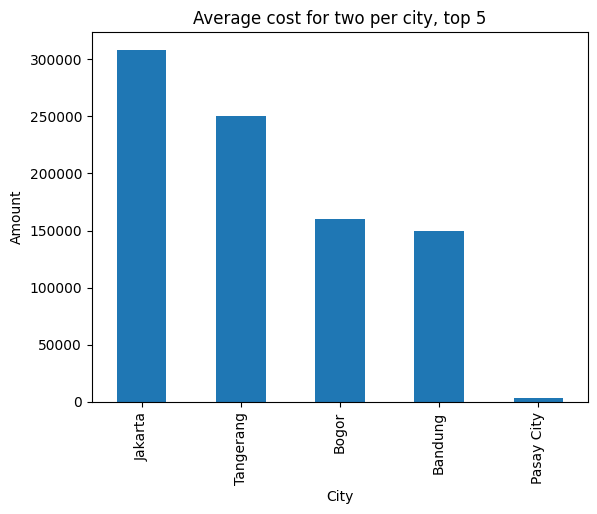

In [119]:
# group by city and calculate average cost
df.groupby("City")["Average Cost for two"].mean().sort_values(ascending=False).head().plot(kind='bar')
plt.title("Average cost for two per city, top 5")
plt.xlabel("City")
plt.ylabel("Amount")
plt.show()


In [121]:
# cuisines total number of votes

data = df.groupby("Cuisines")["Votes"].sum().reset_index()
data

,Cuisines,Votes
0,Afghani,39
1,"Afghani, Mughlai, Chinese",2
2,"Afghani, North Indian",0
3,"Afghani, North Indian, Pakistani, Arabian",3
4,African,373
...,...,...
1821,"Western, Asian, Cafe",259
1822,"Western, Fusion, Fast Food",32
1823,World Cuisine,95
1824,"World Cuisine, Mexican, Italian",115


Text(0, 0.5, 'Votes')

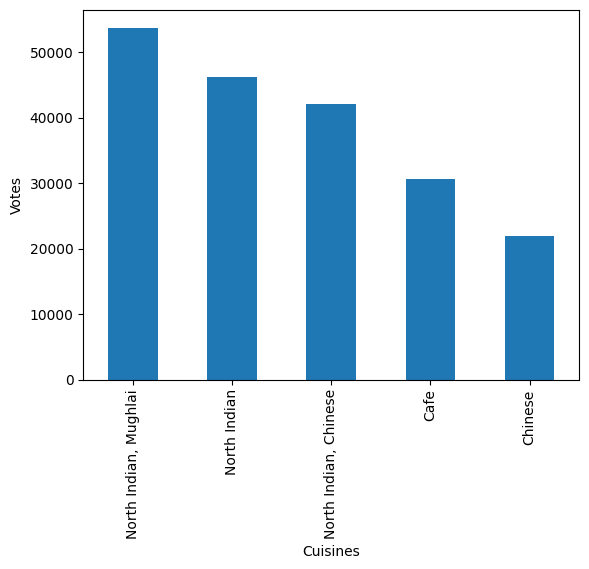

In [122]:
 # Custom total number of votes
df.groupby("Cuisines")["Votes"].sum().sort_values(ascending=False).head().plot(kind="bar")
plt.title("")
plt.xlabel("Cuisines")
plt.ylabel("Votes")


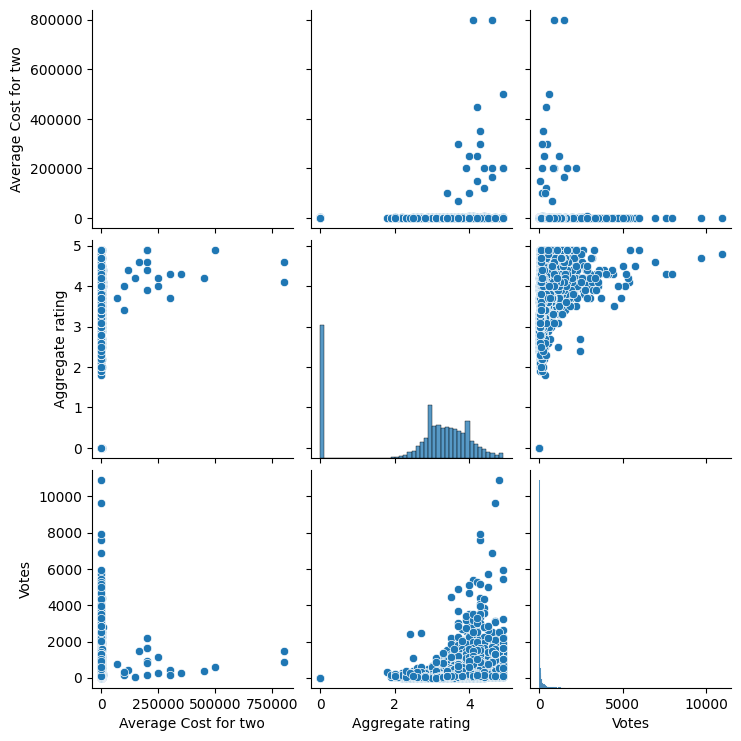

In [123]:
sns.pairplot(df[["Average Cost for two", "Aggregate rating","Votes"]]) 

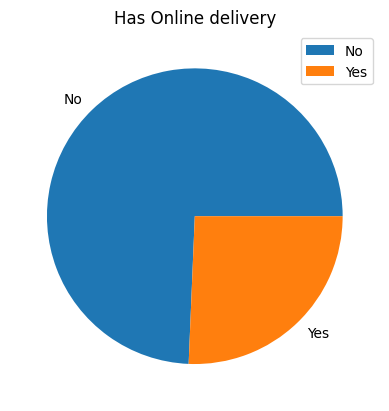

In [124]:

df["Has Online delivery"].value_counts().plot(kind="pie")
plt.title("Has Online delivery")
plt.ylabel("")
plt.legend()
plt.show()


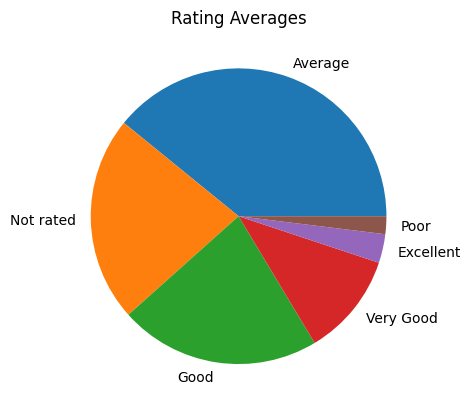

In [125]:
df["Rating text"].value_counts().plot(kind="pie")
plt.title("Rating Averages")
plt.ylabel("")
plt.show()


In [13]:
# remove unnecessary columns

In [14]:
df.drop(columns=[
    'Restaurant ID',
    'Restaurant Name',
    'Address',
    'Rating color',
    'Currency'    
])

,City,Locality,Longitude,Latitude,Cuisines,Average Cost for two,Has Table booking,Has Online delivery,Is delivering now,Price range,Aggregate rating,Rating text,Votes
0,Makati City,"Century City Mall, Poblacion, Makati City",121.027535,14.565443,"French, Japanese, Desserts",1100,Yes,No,No,3,4.8,Excellent,314
1,Makati City,"Little Tokyo, Legaspi Village, Makati City",121.014101,14.553708,Japanese,1200,Yes,No,No,3,4.5,Excellent,591
2,Mandaluyong City,"Edsa Shangri-La, Ortigas, Mandaluyong City",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,Yes,No,No,4,4.4,Very Good,270
3,Mandaluyong City,"SM Megamall, Ortigas, Mandaluyong City",121.056475,14.585318,"Japanese, Sushi",1500,No,No,No,4,4.9,Excellent,365
4,Mandaluyong City,"SM Megamall, Ortigas, Mandaluyong City",121.057508,14.584450,"Japanese, Korean",1500,Yes,No,No,4,4.8,Excellent,229
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9546,ÛÁstanbul,Karakí_y,28.977392,41.022793,Turkish,80,No,No,No,3,4.1,Very Good,788
9547,ÛÁstanbul,Koôuyolu,29.041297,41.009847,"World Cuisine, Patisserie, Cafe",105,No,No,No,3,4.2,Very Good,1034
9548,ÛÁstanbul,Kuruí_eôme,29.034640,41.055817,"Italian, World Cuisine",170,No,No,No,4,3.7,Good,661
9549,ÛÁstanbul,Kuruí_eôme,29.036019,41.057979,Restaurant Cafe,120,No,No,No,4,4.0,Very Good,901


<Axes: ylabel='Average Cost for two'>

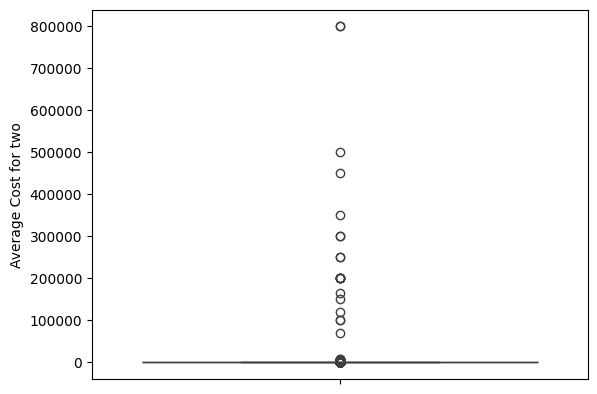

In [17]:
import seaborn as sns

sns.boxplot(df["Average Cost for two"])

In [106]:
from sklearn.utils import resample


In [107]:
 # ⭐ 3. BALANCING (WRITE YOUR CODE HERE 👇)

low = df[df['Aggregate rating'] <= 2]
high = df[df['Aggregate rating'] > 2]

low_upsampled = resample(
    low,
    replace=True,
    n_samples=len(high),
    random_state=42
)

df_balanced = pd.concat([high, low_upsampled])


In [18]:
# 3. Feature Engineering:

In [19]:
df['cost_per_person'] = (
    df["Average Cost for two"]/2
)

In [20]:
df['cost_per_person']

0        550.0
1        600.0
2       2000.0
3        750.0
4        750.0
         ...  
9546      40.0
9547      52.5
9548      85.0
9549      60.0
9550      27.5
Name: cost_per_person, Length: 9551, dtype: float64

## “How expensive a restaurant is compared to its popularity” 

In [21]:
df['cost_per_vote'] = (
    df["Average Cost for two"] / (df['Votes']+1)
)

In [22]:
df['cost_per_vote']

0        3.492063
1        2.027027
2       14.760148
3        4.098361
4        6.521739
          ...    
9546     0.101394
9547     0.101449
9548     0.256798
9549     0.133038
9550     0.092905
Name: cost_per_vote, Length: 9551, dtype: float64

In [23]:
# Encode Categorical Features

In [24]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [33]:
le = LabelEncoder()
scaler = StandardScaler()

In [34]:
df["Has Table booking"] = le.fit_transform(
    df["Has Table booking"]
)

df["Has Online delivery"] = le.fit_transform(
    df["Has Online delivery"]
)

df["Is delivering now"] = le.fit_transform(
    df["Is delivering now"]
)

In [35]:
# One hot encoding

In [38]:
# df = pd.get_dummies(
#     df,
#     columns = [
#         "City",
#         "Locality",
#         "Cuisines"
#     ]
# )

In [39]:
# Step 6: split Features and Target

In [73]:
X  = df[[ 'Average Cost for two', 'Has Table booking','Has Online delivery','Price range','Votes']]
X

,Average Cost for two,Has Table booking,Has Online delivery,Price range,Votes
0,1100,1,0,3,314
1,1200,1,0,3,591
2,4000,1,0,4,270
3,1500,0,0,4,365
4,1500,1,0,4,229
...,...,...,...,...,...
9546,80,0,0,3,788
9547,105,0,0,3,1034
9548,170,0,0,4,661
9549,120,0,0,4,901


In [74]:
y = df["Aggregate rating"]

In [75]:
X = scaler.fit_transform(X)
X

array([[-6.15438439e-03,  2.69218148e+00, -5.87546822e-01,
         1.31980312e+00,  3.65201639e-01],
       [ 4.89590650e-05,  2.69218148e+00, -5.87546822e-01,
         1.31980312e+00,  1.00916810e+00],
       [ 1.73742576e-01,  2.69218148e+00, -5.87546822e-01,
         2.42409043e+00,  2.62910937e-01],
       ...,
       [-6.38454785e-02, -3.71445985e-01, -5.87546822e-01,
         2.42409043e+00,  1.17190331e+00],
       [-6.69471502e-02, -3.71445985e-01, -5.87546822e-01,
         2.42409043e+00,  1.72985259e+00],
       [-7.09793235e-02, -3.71445985e-01, -5.87546822e-01,
         2.15515814e-01,  1.00916810e+00]], shape=(9551, 5))

In [76]:
# Train test split

In [77]:
from sklearn.model_selection import train_test_split

In [78]:
from sklearn.linear_model import LinearRegression

In [79]:
from sklearn.ensemble import RandomForestRegressor

In [80]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size = 0.2,
    random_state = 42
)

In [81]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score


In [82]:
def modelresults(predictions):
    print("Mean absolute error on model is {}".format(mean_absolute_error(y_test,predictions)))
    print("Root mean squared error on model is {}".format(np.sqrt(mean_squared_error(y_test,predictions))))


In [83]:
# LinearRegression

In [84]:
lr = LinearRegression()

In [85]:
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [86]:
# Prediction of LinearRegression

In [87]:
y_pred_lr = lr.predict(X_test)

In [88]:
modelresults(y_pred_lr)

Mean absolute error on model is 1.0750712721369127
Root mean squared error on model is 1.2947896642710524


In [89]:
r2_lr = r2_score(y_test, y_pred_lr)
print("R2 Score : ",r2_lr)

R2 Score :  0.2634446409021949


In [90]:
# Random forest Regressor

In [91]:
rf = RandomForestRegressor()

In [92]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [2,5,10],
    'max_depth': [5, 15]
}

grid = GridSearchCV(
    rf,
    params,
)

In [93]:
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 15], 'n_estimators': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold

In [94]:
print(grid.best_params_)

{'max_depth': 5, 'n_estimators': 10}


In [95]:
best_model = grid.best_estimator_

In [96]:
y_pred_rf = best_model.predict(X_test)

In [97]:
modelresults(y_pred_rf)

Mean absolute error on model is 0.22081383831737364
Root mean squared error on model is 0.33877446699245495


In [98]:
r2_rf = r2_score(y_test, y_pred_rf)
print("R2_score of Random Forest Regressor",r2_rf)

R2_score of Random Forest Regressor 0.9495770457501611


In [99]:
# new_data = [[
#     1000,
#     1,
#     1,
#     3,
#     500,
#     500
# ]]

# new_data = scaler.transform(new_data)

# prediction = best_model.predict(new_data)

# print("Predicted Rating :", prediction[0])       # prediction[0] is used to access the first predicted value from the array returned by the model’s predict() function.

In [102]:
import joblib

joblib.dump(best_model, "restaurant_rating_model1.pkl")



['restaurant_rating_model1.pkl']

In [103]:
joblib.dump(scaler, "scaler1.pkl")

['scaler1.pkl']